In [5]:
import kagglehub
import shutil

path = kagglehub.dataset_download("karakaggle/kaggle-cat-vs-dog-dataset")

destination = "/content/cats_dogs_dataset"

shutil.copytree(path, destination, dirs_exist_ok=True)

print("Saved to:", destination)

Using Colab cache for faster access to the 'kaggle-cat-vs-dog-dataset' dataset.
Saved to: /content/cats_dogs_dataset


In [6]:
import os

os.listdir("/content/cats_dogs_dataset")

['kagglecatsanddogs_3367a']

In [7]:
!zip -r kagglecatsanddogs_3367a.zip /content/cats_dogs_dataset/kagglecatsanddogs_3367a


Streaming output truncated to the last 5000 lines.
  adding: content/cats_dogs_dataset/kagglecatsanddogs_3367a/PetImages/Dog/9162.jpg (deflated 0%)
  adding: content/cats_dogs_dataset/kagglecatsanddogs_3367a/PetImages/Dog/11081.jpg (deflated 1%)
  adding: content/cats_dogs_dataset/kagglecatsanddogs_3367a/PetImages/Dog/10736.jpg (deflated 2%)
  adding: content/cats_dogs_dataset/kagglecatsanddogs_3367a/PetImages/Dog/527.jpg (deflated 7%)
  adding: content/cats_dogs_dataset/kagglecatsanddogs_3367a/PetImages/Dog/11029.jpg (deflated 1%)
  adding: content/cats_dogs_dataset/kagglecatsanddogs_3367a/PetImages/Dog/798.jpg (deflated 3%)
  adding: content/cats_dogs_dataset/kagglecatsanddogs_3367a/PetImages/Dog/6147.jpg (deflated 0%)
  adding: content/cats_dogs_dataset/kagglecatsanddogs_3367a/PetImages/Dog/4491.jpg (deflated 1%)
  adding: content/cats_dogs_dataset/kagglecatsanddogs_3367a/PetImages/Dog/10523.jpg (deflated 1%)
  adding: content/cats_dogs_dataset/kagglecatsanddogs_3367a/PetImages/Dog/

In [8]:
!zip -r kagglecatsanddogs_3367a.zip /content/cats_dogs_dataset/kagglecatsanddogs_3367a

Streaming output truncated to the last 5000 lines.
updating: content/cats_dogs_dataset/kagglecatsanddogs_3367a/PetImages/Dog/9162.jpg (deflated 0%)
updating: content/cats_dogs_dataset/kagglecatsanddogs_3367a/PetImages/Dog/11081.jpg (deflated 1%)
updating: content/cats_dogs_dataset/kagglecatsanddogs_3367a/PetImages/Dog/10736.jpg (deflated 2%)
updating: content/cats_dogs_dataset/kagglecatsanddogs_3367a/PetImages/Dog/527.jpg (deflated 7%)
updating: content/cats_dogs_dataset/kagglecatsanddogs_3367a/PetImages/Dog/11029.jpg (deflated 1%)
updating: content/cats_dogs_dataset/kagglecatsanddogs_3367a/PetImages/Dog/798.jpg (deflated 3%)
updating: content/cats_dogs_dataset/kagglecatsanddogs_3367a/PetImages/Dog/6147.jpg (deflated 0%)
updating: content/cats_dogs_dataset/kagglecatsanddogs_3367a/PetImages/Dog/4491.jpg (deflated 1%)
updating: content/cats_dogs_dataset/kagglecatsanddogs_3367a/PetImages/Dog/10523.jpg (deflated 1%)
updating: content/cats_dogs_dataset/kagglecatsanddogs_3367a/PetImages/Dog/

In [9]:
from google.colab import files
files.download("kagglecatsanddogs_3367a.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("piyushborhade/knn-algorithms")

print("Path to dataset files:", path)

100%|██████████| 1.71k/1.71k [00:00<00:00, 2.23MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/piyushborhade/knn-algorithms/versions/1


In [11]:
import pandas as pd
import os

print(path)

for root, dirs, files in os.walk(path):
    print(files)

/root/.cache/kagglehub/datasets/piyushborhade/knn-algorithms/versions/1
['iphone_purchase_records.csv']


In [12]:
import kagglehub
import pandas as pd
import os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

path = kagglehub.dataset_download("piyushborhade/knn-algorithms")

for file in os.listdir(path):
    if file.endswith(".csv"):
        csv_file = os.path.join(path, file)

df = pd.read_csv(csv_file)

print(df.head())
print(df.info())

le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])

X = df[["Gender", "Age", "Salary"]]
y = df["Purchase Iphone"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

param_grid = {
    "n_neighbors": range(1, 21),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

best_knn = grid.best_estimator_

y_pred = best_knn.predict(X_test)

print("\nBest Parameters:")
print(grid.best_params_)

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Using Colab cache for faster access to the 'knn-algorithms' dataset.
   Gender  Age  Salary  Purchase Iphone
0    Male   19   19000                0
1    Male   35   20000                0
2  Female   26   43000                0
3  Female   27   57000                0
4    Male   19   76000                0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Gender           400 non-null    object
 1   Age              400 non-null    int64 
 2   Salary           400 non-null    int64 
 3   Purchase Iphone  400 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 12.6+ KB
None

Best Parameters:
{'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}

Accuracy:
0.9

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92        51
           1       0.84      0.

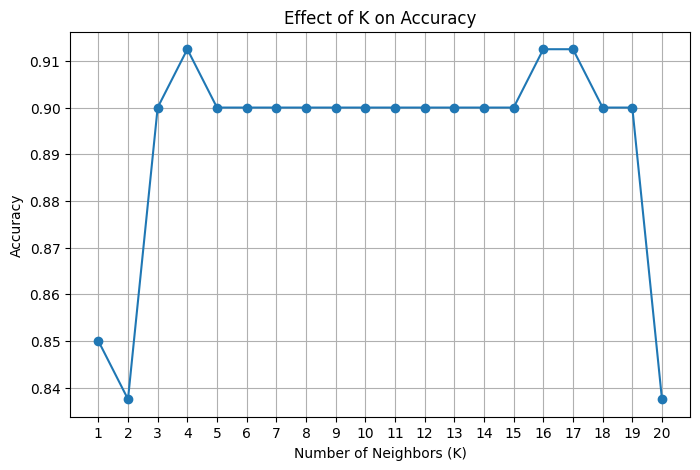

In [13]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    accuracies.append(
        accuracy_score(y_test, y_pred)
    )

plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    accuracies,
    marker="o"
)

plt.title("Effect of K on Accuracy")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.xticks(k_values)
plt.grid(True)

plt.show()